# Downloading airborne magnetics from USGS Project 4277 in the Dixie Valley, Nevada

Accessed from https://usgs.maps.arcgis.com/apps/webappviewer/index.html?id=df7d8461533540c694177f5e0150deec

Metadata: https://mrdata.usgs.gov/geophysics/surveys/geophysics2/NV/NV_4277_META.txt

In [1]:
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
import verde as vd

import airbornegeo

## load data

In [2]:
fname = pooch.retrieve(
    url="https://mrdata.usgs.gov/geophysics/surveys/geophysics2/NV/NV_4277.zip",
    progressbar=True,
    path=f"{pooch.os_cache('airbornegeo')}",
    processor=pooch.Unzip(members=["NV_4277_contractor.xyz"]),
)[0]
data_df = pd.read_csv(
    fname,
    header=None,
    sep=r"\s+",
    names=[
        "line",
        "lon_nad83",
        "lat_nad83",
        "lon_nad27",
        "lat_nad27",
        "easting",  # utm WGS-84
        "northing",  # utm WGS-84
        "x66",  # utm Clarke 1866
        "y66",  # utm Clarke 1866
        "fid",
        "date",
        "time",
        "radar",  # radar altimeter
        "gps_elev",  # gps elevation
        "topography",
        "diurnal",
        "raw_mag",  # raw mag
        "diu_mag",  # diurnal corrected mag
        "res_mag",
        "dc_levelled_mag",
        "final_mag",  # levelled
        "igrf_corrected_mag",
    ],
)

data_df = data_df.replace(
    [
        99999.9,
        99999.999,
    ],
    np.nan,
)

data_df

,line,lon_nad83,lat_nad83,lon_nad27,lat_nad27,easting,northing,x66,y66,fid,...,radar,gps_elev,topography,diurnal,raw_mag,diu_mag,res_mag,dc_levelled_mag,final_mag,igrf_corrected_mag
0,11,-117.94759,39.66368,-117.94663,39.66376,418717.9,4390858.9,418798.2,4390657.8,1,...,129.1,1439.0,1310.4,51501.36,51254.409,51624.883,-38.298,-36.611,-36.611,-408.771
1,11,-117.94759,39.66369,-117.94663,39.66377,418718.2,4390860.4,418798.5,4390659.2,2,...,128.7,1438.8,1310.7,51501.36,51254.572,51625.046,-38.147,-36.461,-36.461,-408.621
2,11,-117.94758,39.66370,-117.94662,39.66379,418718.5,4390861.9,418798.8,4390660.7,3,...,128.0,1438.7,1311.2,51501.36,51254.711,51625.184,-38.016,-36.330,-36.330,-408.489
3,11,-117.94758,39.66371,-117.94662,39.66379,418718.7,4390862.7,418799.0,4390661.5,4,...,128.9,1438.5,1310.2,51501.36,51254.873,51625.346,-37.866,-36.180,-36.180,-408.340
4,11,-117.94758,39.66373,-117.94662,39.66381,418719.0,4390864.1,418799.4,4390662.9,5,...,129.3,1438.4,1309.6,51501.36,51255.004,51625.477,-37.748,-36.061,-36.061,-408.221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1424833,500,-117.87362,39.78466,-117.87266,39.78474,425193.6,4404221.8,425273.8,4404020.6,4916,...,34.3,1174.9,1137.2,51497.00,52011.296,52386.220,634.056,632.948,612.244,259.133
1424834,500,-117.87361,39.78465,-117.87265,39.78473,425194.8,4404220.9,425275.0,4404019.6,4917,...,34.5,1175.0,1137.3,51497.00,52010.732,52385.656,633.500,632.728,612.029,258.576
1424835,500,-117.87359,39.78464,-117.87264,39.78472,425196.0,4404219.9,425276.2,4404018.7,4918,...,34.6,1175.1,1137.4,51497.00,52010.133,52385.057,632.909,632.508,611.823,257.985
1424836,500,-117.87358,39.78463,-117.87262,39.78472,425197.2,4404218.9,425277.4,4404017.7,4919,...,34.5,1175.2,1137.5,51497.00,52009.613,52384.537,632.396,632.289,611.607,257.472


In [3]:
data_df.describe()

,line,lon_nad83,lat_nad83,lon_nad27,lat_nad27,easting,northing,x66,y66,fid,radar,gps_elev,topography,diurnal,raw_mag,diu_mag,res_mag,dc_levelled_mag,final_mag,igrf_corrected_mag
count,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424836e+06,1.424838e+06,1.424836e+06,1.424838e+06,1.424838e+06,1.424701e+06,1.424714e+06,1.424714e+06,1.424701e+06,1.424714e+06
mean,2.815032e+02,-1.178817e+02,3.987699e+01,-1.178808e+02,3.987708e+01,4.245902e+05,4.414483e+06,4.246703e+05,4.414282e+06,2.994186e+03,1.337727e+02,1.260778e+03,1.126787e+03,5.151668e+04,5.169660e+04,5.205250e+04,2.507499e+02,2.505056e+02,2.105586e+02,-1.045708e+02
std,3.674577e+02,1.161464e-01,1.014426e-01,1.161425e-01,1.014435e-01,1.000596e+04,1.119449e+04,1.000579e+04,1.119446e+04,2.267322e+03,1.688124e+01,1.435709e+02,1.494315e+02,1.077901e+01,1.954357e+02,1.588036e+02,1.394993e+02,1.392806e+02,1.585256e+02,1.400784e+02
min,1.000000e+00,-1.181499e+02,3.965062e+01,-1.181489e+02,3.965070e+01,4.014977e+05,4.389434e+06,4.015781e+05,4.389233e+06,1.000000e+00,2.530000e+01,1.064400e+03,1.010700e+03,5.149520e+04,1.589871e+04,5.124883e+04,-5.999990e+02,-6.007520e+02,-6.007520e+02,-9.567490e+02
25%,7.400000e+01,-1.179739e+02,3.979499e+01,-1.179730e+02,3.979507e+01,4.166209e+05,4.405454e+06,4.167012e+05,4.405252e+06,1.339000e+03,1.278000e+02,1.173900e+03,1.034800e+03,5.150880e+04,5.159639e+04,5.195329e+04,1.654202e+02,1.655450e+02,1.177380e+02,-1.904500e+02
50%,1.440000e+02,-1.178817e+02,3.987939e+01,-1.178808e+02,3.987948e+01,4.245872e+05,4.414744e+06,4.246673e+05,4.414543e+06,2.700000e+03,1.351000e+02,1.206700e+03,1.069900e+03,5.151667e+04,5.169633e+04,5.205151e+04,2.174950e+02,2.172490e+02,1.965650e+02,-1.373880e+02
75%,2.150000e+02,-1.177930e+02,3.995781e+01,-1.177920e+02,3.995789e+01,4.322684e+05,4.423388e+06,4.323484e+05,4.423187e+06,4.070000e+03,1.420000e+02,1.289900e+03,1.153000e+03,5.152315e+04,5.178209e+04,5.213736e+04,3.029500e+02,3.024237e+02,2.813040e+02,-5.260000e+01
max,1.210000e+03,-1.176066e+02,4.009972e+01,-1.176056e+02,4.009981e+01,4.482058e+05,4.439129e+06,4.482855e+05,4.438928e+06,1.474000e+04,3.182000e+02,2.300000e+03,2.184100e+03,5.153850e+04,5.288586e+04,5.323643e+04,1.428358e+03,1.426683e+03,1.426683e+03,1.077788e+03


In [4]:
data_df[["date", "time"]]

,date,time
0,2002/01/23,12:37:22.55
1,2002/01/23,12:37:22.66
2,2002/01/23,12:37:22.71
3,2002/01/23,12:37:22.82
4,2002/01/23,12:37:22.93
...,...,...
1424833,2002/01/31,12:11:57.76
1424834,2002/01/31,12:11:57.87
1424835,2002/01/31,12:11:57.98
1424836,2002/01/31,12:11:58.09


In [5]:
# convert line ID's from strings to unique floats
data_df["line"] = airbornegeo.unique_line_id(
    data_df,
    line_col_name="line",
)

# make unixtime colum
data_df["date"] = pd.to_datetime(data_df["date"])
data_df["time"] = pd.to_timedelta(data_df["time"])
data_df["unixtime"] = data_df["date"] + data_df["time"]
data_df = data_df.dropna(subset=["unixtime"])
data_df["unixtime"] = data_df["unixtime"].apply(lambda x: x.timestamp())

# sort by line then time and reset index
data_df = data_df.sort_values(["line", "unixtime"]).reset_index(drop=True)

data_df

,line,lon_nad83,lat_nad83,lon_nad27,lat_nad27,easting,northing,x66,y66,fid,...,gps_elev,topography,diurnal,raw_mag,diu_mag,res_mag,dc_levelled_mag,final_mag,igrf_corrected_mag,unixtime
0,1,-117.94759,39.66368,-117.94663,39.66376,418717.9,4390858.9,418798.2,4390657.8,1,...,1439.0,1310.4,51501.36,51254.409,51624.883,-38.298,-36.611,-36.611,-408.771,1.011789e+09
1,1,-117.94759,39.66369,-117.94663,39.66377,418718.2,4390860.4,418798.5,4390659.2,2,...,1438.8,1310.7,51501.36,51254.572,51625.046,-38.147,-36.461,-36.461,-408.621,1.011789e+09
2,1,-117.94758,39.66370,-117.94662,39.66379,418718.5,4390861.9,418798.8,4390660.7,3,...,1438.7,1311.2,51501.36,51254.711,51625.184,-38.016,-36.330,-36.330,-408.489,1.011789e+09
3,1,-117.94758,39.66371,-117.94662,39.66379,418718.7,4390862.7,418799.0,4390661.5,4,...,1438.5,1310.2,51501.36,51254.873,51625.346,-37.866,-36.180,-36.180,-408.340,1.011789e+09
4,1,-117.94758,39.66373,-117.94662,39.66381,418719.0,4390864.1,418799.4,4390662.9,5,...,1438.4,1309.6,51501.36,51255.004,51625.477,-37.748,-36.061,-36.061,-408.221,1.011789e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1424833,267,-117.87362,39.78466,-117.87266,39.78474,425193.6,4404221.8,425273.8,4404020.6,4916,...,1174.9,1137.2,51497.00,52011.296,52386.220,634.056,632.948,612.244,259.133,1.012479e+09
1424834,267,-117.87361,39.78465,-117.87265,39.78473,425194.8,4404220.9,425275.0,4404019.6,4917,...,1175.0,1137.3,51497.00,52010.732,52385.656,633.500,632.728,612.029,258.576,1.012479e+09
1424835,267,-117.87359,39.78464,-117.87264,39.78472,425196.0,4404219.9,425276.2,4404018.7,4918,...,1175.1,1137.4,51497.00,52010.133,52385.057,632.909,632.508,611.823,257.985,1.012479e+09
1424836,267,-117.87358,39.78463,-117.87262,39.78472,425197.2,4404218.9,425277.4,4404017.7,4919,...,1175.2,1137.5,51497.00,52009.613,52384.537,632.396,632.289,611.607,257.472,1.012479e+09


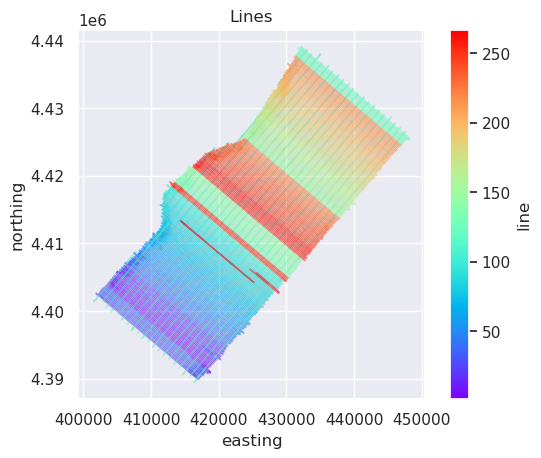

In [6]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.002,
    cmap="rainbow",
    title="Lines",
)
ax.set_aspect("equal")

In [7]:
data_df.columns

Index(['line', 'lon_nad83', 'lat_nad83', 'lon_nad27', 'lat_nad27', 'easting',
       'northing', 'x66', 'y66', 'fid', 'date', 'time', 'radar', 'gps_elev',
       'topography', 'diurnal', 'raw_mag', 'diu_mag', 'res_mag',
       'dc_levelled_mag', 'final_mag', 'igrf_corrected_mag', 'unixtime'],
      dtype='str')

In [8]:
data_df[
    [
        "line",
        "lon_nad83",
        "lat_nad83",
        "lon_nad27",
        "lat_nad27",
        "easting",
        "northing",
        "x66",
        "y66",
        "fid",
        "date",
        "time",
        "radar",
        "gps_elev",
        "topography",
    ]
].describe()

,line,lon_nad83,lat_nad83,lon_nad27,lat_nad27,easting,northing,x66,y66,fid,date,time,radar,gps_elev,topography
count,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1.424838e+06,1424838,1424838,1.424836e+06,1.424838e+06,1.424836e+06
mean,1.327538e+02,-1.178817e+02,3.987699e+01,-1.178808e+02,3.987708e+01,4.245902e+05,4.414483e+06,4.246703e+05,4.414282e+06,2.994186e+03,2002-01-27 01:34:21.935462,0 days 11:58:44.489321,1.337727e+02,1.260778e+03,1.126787e+03
min,1.000000e+00,-1.181499e+02,3.965062e+01,-1.181489e+02,3.965070e+01,4.014977e+05,4.389434e+06,4.015781e+05,4.389233e+06,1.000000e+00,2002-01-23 00:00:00,0 days 07:43:39.260000,2.530000e+01,1.064400e+03,1.010700e+03
25%,7.500000e+01,-1.179739e+02,3.979499e+01,-1.179730e+02,3.979507e+01,4.166209e+05,4.405454e+06,4.167012e+05,4.405252e+06,1.339000e+03,2002-01-25 00:00:00,0 days 09:37:21.120000,1.278000e+02,1.173900e+03,1.034800e+03
50%,1.230000e+02,-1.178817e+02,3.987939e+01,-1.178808e+02,3.987948e+01,4.245872e+05,4.414744e+06,4.246673e+05,4.414543e+06,2.700000e+03,2002-01-27 00:00:00,0 days 12:38:19.640000,1.351000e+02,1.206700e+03,1.069900e+03
75%,1.950000e+02,-1.177930e+02,3.995781e+01,-1.177920e+02,3.995789e+01,4.322684e+05,4.423388e+06,4.323484e+05,4.423187e+06,4.070000e+03,2002-01-29 00:00:00,0 days 14:16:10.440000,1.420000e+02,1.289900e+03,1.153000e+03
max,2.670000e+02,-1.176066e+02,4.009972e+01,-1.176056e+02,4.009981e+01,4.482058e+05,4.439129e+06,4.482855e+05,4.438928e+06,1.474000e+04,2002-01-31 00:00:00,0 days 16:10:33.210000,3.182000e+02,2.300000e+03,2.184100e+03
std,7.357694e+01,1.161464e-01,1.014426e-01,1.161425e-01,1.014435e-01,1.000596e+04,1.119449e+04,1.000579e+04,1.119446e+04,2.267322e+03,NaN,0 days 02:30:23.942145,1.688124e+01,1.435709e+02,1.494315e+02


In [9]:
data_df[
    [
        "diurnal",
        "raw_mag",
        "diu_mag",
        "res_mag",
        "dc_levelled_mag",
        "final_mag",
        "igrf_corrected_mag",
    ]
].describe()

# column with nans: diu_mag, res_mag, dc_levelled_mag, final_mag, igrf_corrected_mag

,diurnal,raw_mag,diu_mag,res_mag,dc_levelled_mag,final_mag,igrf_corrected_mag
count,1.424838e+06,1.424838e+06,1.424701e+06,1.424714e+06,1.424714e+06,1.424701e+06,1.424714e+06
mean,5.151668e+04,5.169660e+04,5.205250e+04,2.507499e+02,2.505056e+02,2.105586e+02,-1.045708e+02
std,1.077901e+01,1.954357e+02,1.588036e+02,1.394993e+02,1.392806e+02,1.585256e+02,1.400784e+02
min,5.149520e+04,1.589871e+04,5.124883e+04,-5.999990e+02,-6.007520e+02,-6.007520e+02,-9.567490e+02
25%,5.150880e+04,5.159639e+04,5.195329e+04,1.654202e+02,1.655450e+02,1.177380e+02,-1.904500e+02
50%,5.151667e+04,5.169633e+04,5.205151e+04,2.174950e+02,2.172490e+02,1.965650e+02,-1.373880e+02
75%,5.152315e+04,5.178209e+04,5.213736e+04,3.029500e+02,3.024237e+02,2.813040e+02,-5.260000e+01
max,5.153850e+04,5.288586e+04,5.323643e+04,1.428358e+03,1.426683e+03,1.426683e+03,1.077788e+03


In [10]:
51254.409 - 51501.36

-246.95100000000093

In [11]:
data_df[
    [
        "diurnal",
        "raw_mag",
        "diu_mag",
        "res_mag",
        "dc_levelled_mag",
        "final_mag",
        "igrf_corrected_mag",
    ]
].head(10)

,diurnal,raw_mag,diu_mag,res_mag,dc_levelled_mag,final_mag,igrf_corrected_mag
0,51501.36,51254.409,51624.883,-38.298,-36.611,-36.611,-408.771
1,51501.36,51254.572,51625.046,-38.147,-36.461,-36.461,-408.621
2,51501.36,51254.711,51625.184,-38.016,-36.330,-36.330,-408.489
3,51501.36,51254.873,51625.346,-37.866,-36.180,-36.180,-408.340
4,51501.36,51255.004,51625.477,-37.748,-36.061,-36.061,-408.221
5,51501.36,51255.182,51625.655,-37.582,-35.896,-35.896,-408.055
6,51501.36,51255.360,51625.833,-37.416,-35.730,-35.730,-407.890
7,51501.36,51255.499,51625.972,-37.286,-35.600,-35.600,-407.759
8,51501.36,51255.684,51626.157,-37.113,-35.427,-35.427,-407.586
9,51501.36,51255.869,51626.342,-36.941,-35.254,-35.254,-407.414


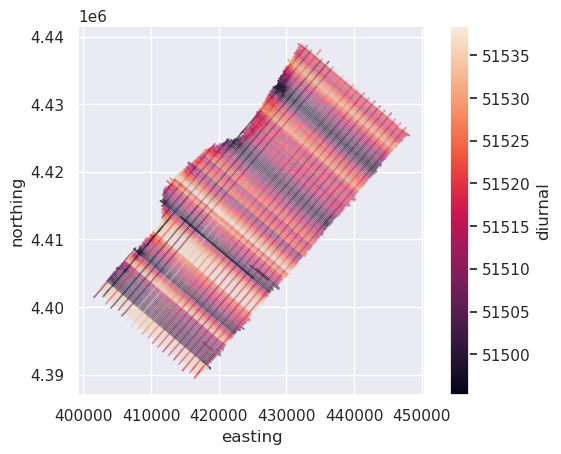

In [12]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="diurnal",
    s=0.002,
)
ax.set_aspect("equal")

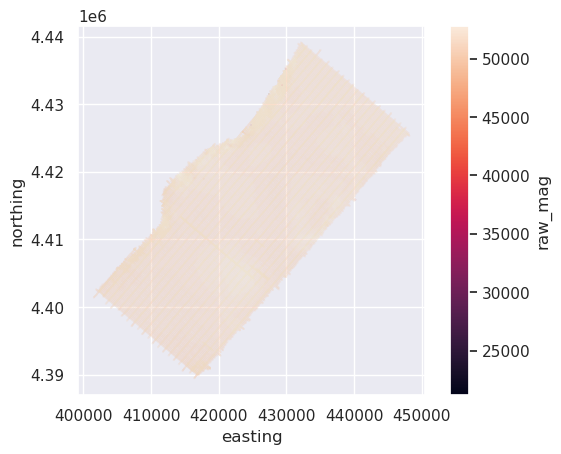

In [13]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="raw_mag",
    s=0.002,
)
ax.set_aspect("equal")

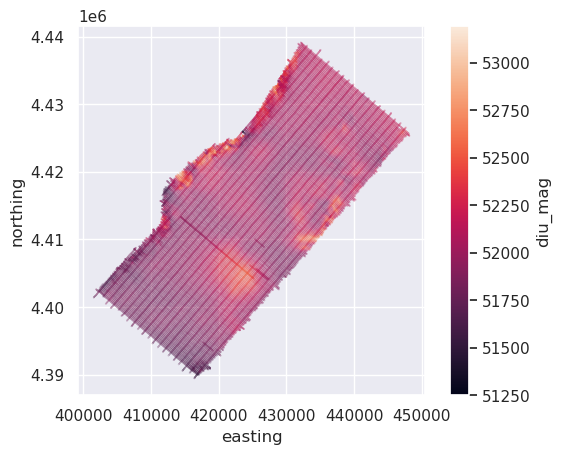

In [14]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="diu_mag",
    s=0.002,
)
ax.set_aspect("equal")

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


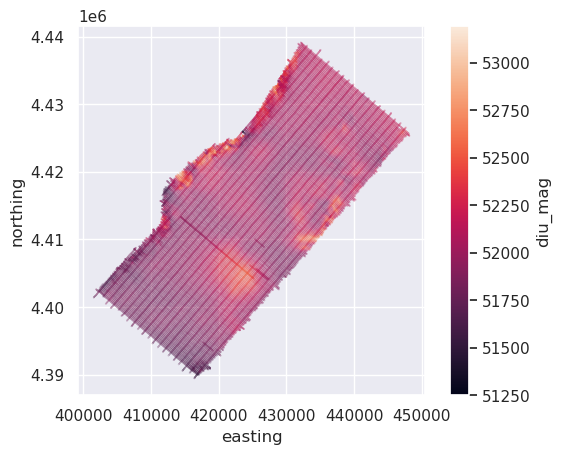

In [15]:
df = data_df[::10]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="diu_mag",
    s=0.002,
)
ax.set_aspect("equal")

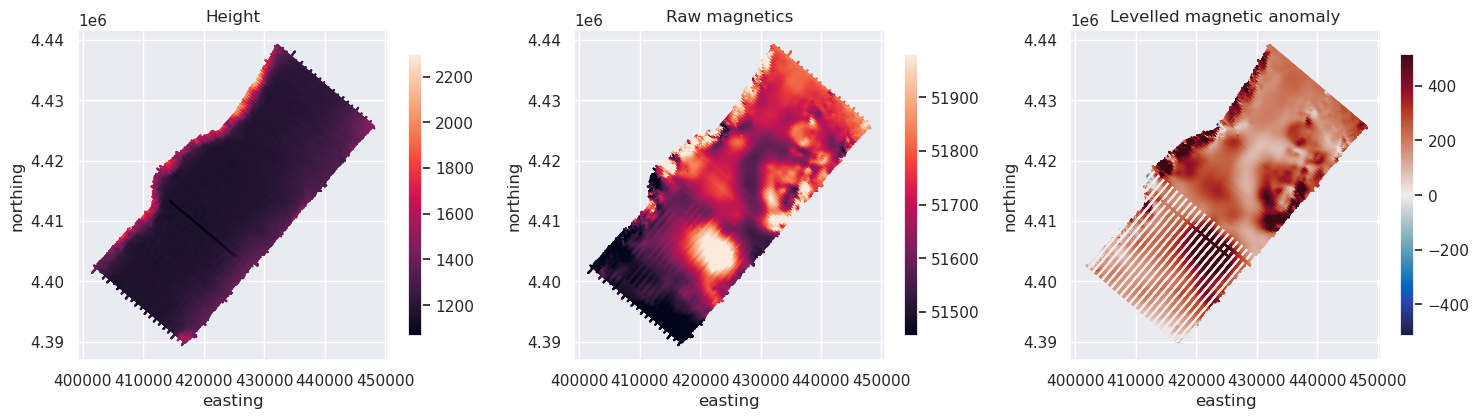

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

df = data_df[::10]

ax = df.plot.scatter(
    "easting",
    "northing",
    c="gps_elev",
    s=0.2,
    ax=axs[0],
    colorbar=False,
    title="Height",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

cpt_lims = vd.minmax(data_df.raw_mag, min_percentile=5, max_percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="raw_mag",
    s=0.2,
    ax=axs[1],
    colorbar=False,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
    title="Raw magnetics",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.final_mag, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="final_mag",
    s=0.2,
    ax=axs[2],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="Levelled magnetic anomaly",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()